# Tugas Besar Visualisasi Data dan Informasi 2024


# Import Dataset


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the uploaded CSV file to examine its structure
file_path1 = 'dataset_TSMC2014_NYC.csv'
file_path2 = 'dataset_TSMC2014_TKY.csv'
data = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)




melakukan import libary Pandas, matplotlib, dan seaborn. Setelah itu membuat sebuah variabel file_path1 dan file_path2 yang berisi path dari dataset yang akan digunakan. Kemudian menggunakan fungsi pd.read_csv() untuk membaca dataset yang akan digunakan.

In [82]:
#5 data teratas untuk data NYC
data.head()


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012


In [83]:
#5 data teratas untuk data tokyo
data2.head()


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540,Tue Apr 03 18:17:18 +0000 2012
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540,Tue Apr 03 18:22:04 +0000 2012
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540,Tue Apr 03 19:12:07 +0000 2012
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540,Tue Apr 03 19:12:13 +0000 2012
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734046,540,Tue Apr 03 19:18:23 +0000 2012


# Preprocessing Dataset NYC dan TKY

## Menghapus data yang tidak diperlukan

In [84]:
#informasi terkait data nyc dan tky
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227428 entries, 0 to 227427
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   userId           227428 non-null  int64  
 1   venueId          227428 non-null  object 
 2   venueCategoryId  227428 non-null  object 
 3   venueCategory    227428 non-null  object 
 4   latitude         227428 non-null  float64
 5   longitude        227428 non-null  float64
 6   timezoneOffset   227428 non-null  int64  
 7   utcTimestamp     227428 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 13.9+ MB


In [85]:
data2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573703 entries, 0 to 573702
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   userId           573703 non-null  int64  
 1   venueId          573703 non-null  object 
 2   venueCategoryId  573703 non-null  object 
 3   venueCategory    573703 non-null  object 
 4   latitude         573703 non-null  float64
 5   longitude        573703 non-null  float64
 6   timezoneOffset   573703 non-null  int64  
 7   utcTimestamp     573703 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 35.0+ MB


Karena tidak ditemukan data kosong pada kedua dataset, maka tidak perlu dilakukan data cleaning atau removing data.

## Spliting Data NYC dan TKY

In [86]:
#konversi tipe data pada kolom utctimestamp menjadi datetime dataset NYC
data['utcTimestamp'] = pd.to_datetime(data['utcTimestamp'], utc=True)

# Ekstrak informasi tanggal, hari, dan jam dari kolom utcTimestamp dataset NYC
data['date'] = data['utcTimestamp'].dt.date
data['day_of_week'] = data['utcTimestamp'].dt.day_name()
data['hour'] = data['utcTimestamp'].dt.hour

#konversi tipe data pada kolom utctimestamp menjadi datetime dataset Tokyo
data2['utcTimestamp'] = pd.to_datetime(data2['utcTimestamp'], utc=True)

# # Ekstrak informasi tanggal, hari, dan jam dari kolom utcTimestamp dataset Tokyo
data2['date'] = data2['utcTimestamp'].dt.date
data2['day_of_week'] = data2['utcTimestamp'].dt.day_name()
data2['hour'] = data2['utcTimestamp'].dt.hour



C:\Users\PF3DG\AppData\Local\Temp\ipykernel_2480\389416204.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['utcTimestamp'] = pd.to_datetime(data['utcTimestamp'], utc=True)
C:\Users\PF3DG\AppData\Local\Temp\ipykernel_2480\389416204.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data2['utcTimestamp'] = pd.to_datetime(data2['utcTimestamp'], utc=True)


In [87]:
data.head()


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp,date,day_of_week,hour
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,2012-04-03 18:00:09+00:00,2012-04-03,Tuesday,18
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,2012-04-03 18:00:25+00:00,2012-04-03,Tuesday,18
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,2012-04-03 18:02:24+00:00,2012-04-03,Tuesday,18
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,2012-04-03 18:02:41+00:00,2012-04-03,Tuesday,18
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,2012-04-03 18:03:00+00:00,2012-04-03,Tuesday,18


In [88]:
data2.head()


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp,date,day_of_week,hour
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540,2012-04-03 18:17:18+00:00,2012-04-03,Tuesday,18
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540,2012-04-03 18:22:04+00:00,2012-04-03,Tuesday,18
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540,2012-04-03 19:12:07+00:00,2012-04-03,Tuesday,19
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540,2012-04-03 19:12:13+00:00,2012-04-03,Tuesday,19
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734046,540,2012-04-03 19:18:23+00:00,2012-04-03,Tuesday,19


# Visualisasi Data

## Menghitung 10 kategori temppat teramai pada dataset NYC dam TKY


In [89]:
#10 kategori venue teramai dikunjungi dataset NYC
hitung_category = data['venueCategory'].value_counts()
category_df = pd.DataFrame(hitung_category)
#hitung banyak kategori venue,ambil nilai total kategori dataset NYC
total_kategori = len(hitung_category)
print(f'Jumlah Kategori Venue di New York City: {total_kategori}')
category_df.head(10)



Jumlah Kategori Venue di New York City: 251


,count
venueCategory,
Bar,15978
Home (private),15382
Office,12740
Subway,9348
Gym / Fitness Center,9171
Coffee Shop,7510
Food & Drink Shop,6596
Train Station,6408
Park,4804


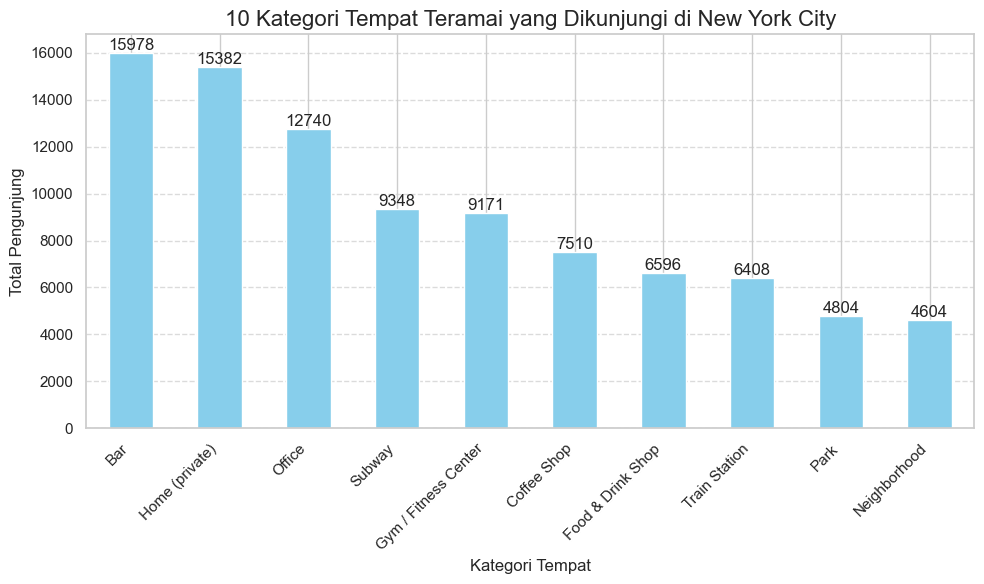

In [90]:
# Persebaran 10 tempat teramai dikunjungi di daerah new york city
import matplotlib.pyplot as plt

# Distribusi kategori tempat
category_counts = data['venueCategory'].value_counts().head(10)  # Top 10 categories

# Visualisasi
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('10 Kategori Tempat Teramai yang Dikunjungi di New York City', fontsize=16)
plt.xlabel('Kategori Tempat', fontsize=12)
plt.ylabel('Total Pengunjung', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for i, count in enumerate(category_counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.show()


In [91]:
#rata-rata user yang mengunjungi 10 tempat teramai 
top_10_category = data['venueCategory'].value_counts().head(10).index
top_10_category_data = data[data['venueCategory'].isin(top_10_category)]

average_user_count = top_10_category_data['userId'].value_counts().mean()
print(f'Rata-rata User yang Mengunjungi 10 Tempat Teramai: {average_user_count:.0f} User')

#rata-rata kunjungan pertempat kategori
average_visit = top_10_category_data.groupby('venueCategory')['userId'].value_counts().mean()
print(f'Rata-rata Kunjungan ke Tempat Kategori: {average_visit:.0f} Kali')


Rata-rata User yang Mengunjungi 10 Tempat Teramai: 86 User
Rata-rata Kunjungan ke Tempat Kategori: 14 Kali


In [128]:
#10 kategori venue teramai dikunjungi dataset Tokyo
hitung_category2 = data2['venueCategory'].value_counts()
category_df2 = pd.DataFrame(hitung_category2)
#hitung banyak kategori venue,ambil nilai total kategori dataset Tokyo
total_kategori2 = len(hitung_category2)
print(f'Jumlah Kategori Venue di Tokyo: {total_kategori2}')
category_df2.head(10)


Jumlah Kategori Venue di Tokyo: 247


,count
venueCategory,
Train Station,200428
Subway,41666
Ramen / Noodle House,17303
Convenience Store,16833
Japanese Restaurant,15680
Bar,14940
Food & Drink Shop,14023
Electronics Store,10897
Mall,10839


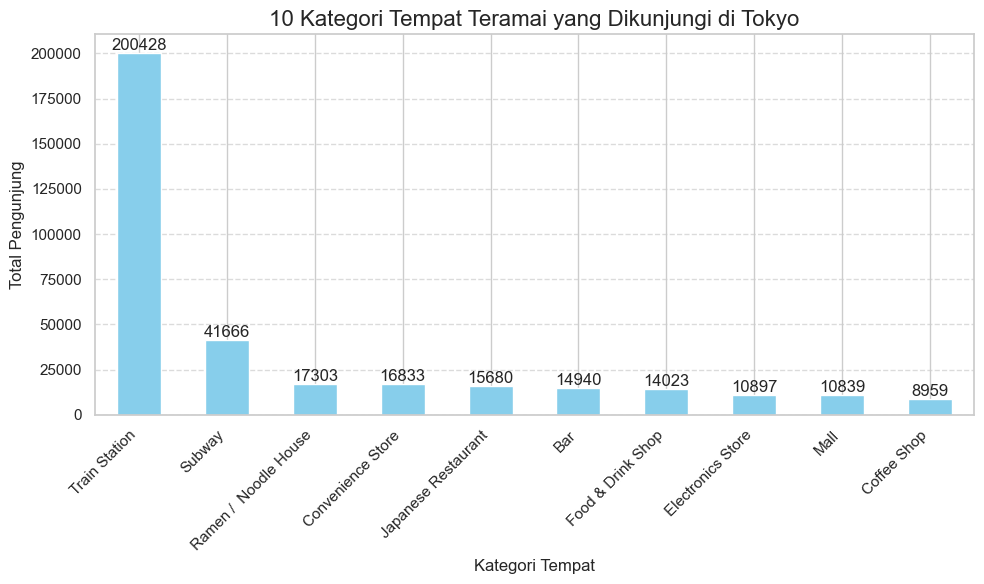

In [129]:
# Persebaran 10 tempat teramai dikunjungi di daerah newyork city
import matplotlib.pyplot as plt

# Distribusi kategori tempat
category_counts2 = data2['venueCategory'].value_counts().head(10)  # Top 10 categories

# Visualisasi
plt.figure(figsize=(10, 6))
category_counts2.plot(kind='bar', color='skyblue')
plt.title('10 Kategori Tempat Teramai yang Dikunjungi di Tokyo', fontsize=16)
plt.xlabel('Kategori Tempat', fontsize=12)
plt.ylabel('Total Pengunjung', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for i, count in enumerate(category_counts2):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.show()


In [94]:
#Hitung rata-rata user yang mengunjungi 10 tempat teramai 
top_10_category2 = data2['venueCategory'].value_counts().head(10).index
top_10_category_data2 = data2[data2['venueCategory'].isin(top_10_category)]
average_user_count2 = top_10_category_data2['userId'].value_counts().mean()
print(f'Rata-rata User yang Mengunjungi 10 Tempat Teramai: {average_user_count:.0f} User')

#hitung rata-rata kunjungan pertemmpat kategori
average_visit2 = top_10_category_data2.groupby('venueCategory')['userId'].value_counts().mean()
print(f'Rata-rata Kunjungan ke Tempat Kategori: {average_visit2:.0f} Kali')




Rata-rata User yang Mengunjungi 10 Tempat Teramai: 86 User
Rata-rata Kunjungan ke Tempat Kategori: 26 Kali


## Jumlah Pengunjung Berdasarkan Hari, dan Waktu pada Dataset NYC dan TKY

In [95]:
#identifikasi 10 tempat teramai yang dikunjungi di New York City
top_venues = data['venueCategory'].value_counts().head(10).index

#filter data untuk hanya 10 tempat teratas
top_venues_data = data[data['venueCategory'].isin(top_venues)]

#hitung kunjungan berdasarkan hari perminggu
#urutan hari 
visits_by_day = top_venues_data.groupby(['venueCategory', 'day_of_week']).size().unstack(fill_value=0)

#hitung kunjungan berdasarkan jam
visits_by_hour = top_venues_data.groupby(['venueCategory', 'hour']).size().unstack(fill_value=0)


#identifikasi 10 tempat teramai yang dikunjungi di Tokyo
top_venues2 = data2['venueCategory'].value_counts().head(10).index
#filter data untuk hanya 10 tempat teratas
top_venues_data2 = data2[data2['venueCategory'].isin(top_venues2)]
#hitung kunjungan berdasarkan hari perminggu
#urutan hari
visits_by_day2 = top_venues_data2.groupby(['venueCategory', 'day_of_week']).size().unstack(fill_value=0)
#hitung kunjungan berdasarkan jam
visits_by_hour2 = top_venues_data2.groupby(['venueCategory', 'hour']).size().unstack(fill_value=0)


### Jumlah Pengunjung Berdasarkan Hari 

In [96]:
#urutkan berdasarkan hari
days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
visits_by_day = visits_by_day.reindex(columns=days) #untuk dataset NYC
visits_by_day2 = visits_by_day2.reindex(columns=days) #untuk dataset Tokyo



In [97]:
#dataset NYC
visits_by_day


day_of_week,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
venueCategory,,,,,,,
Bar,3855,1407,1370,1646,1854,2042,3804
Coffee Shop,832,1222,1164,1100,1082,1209,901
Food & Drink Shop,1196,929,834,805,731,931,1170
Gym / Fitness Center,910,1490,1618,1532,1291,1246,1084
Home (private),2506,2170,2086,2056,2117,2073,2374
Neighborhood,664,741,659,638,586,667,649
Office,373,2635,2507,2197,2107,2414,507
Park,885,726,633,543,591,588,838
Subway,927,1559,1594,1446,1345,1448,1029


<Figure size 1200x600 with 0 Axes>

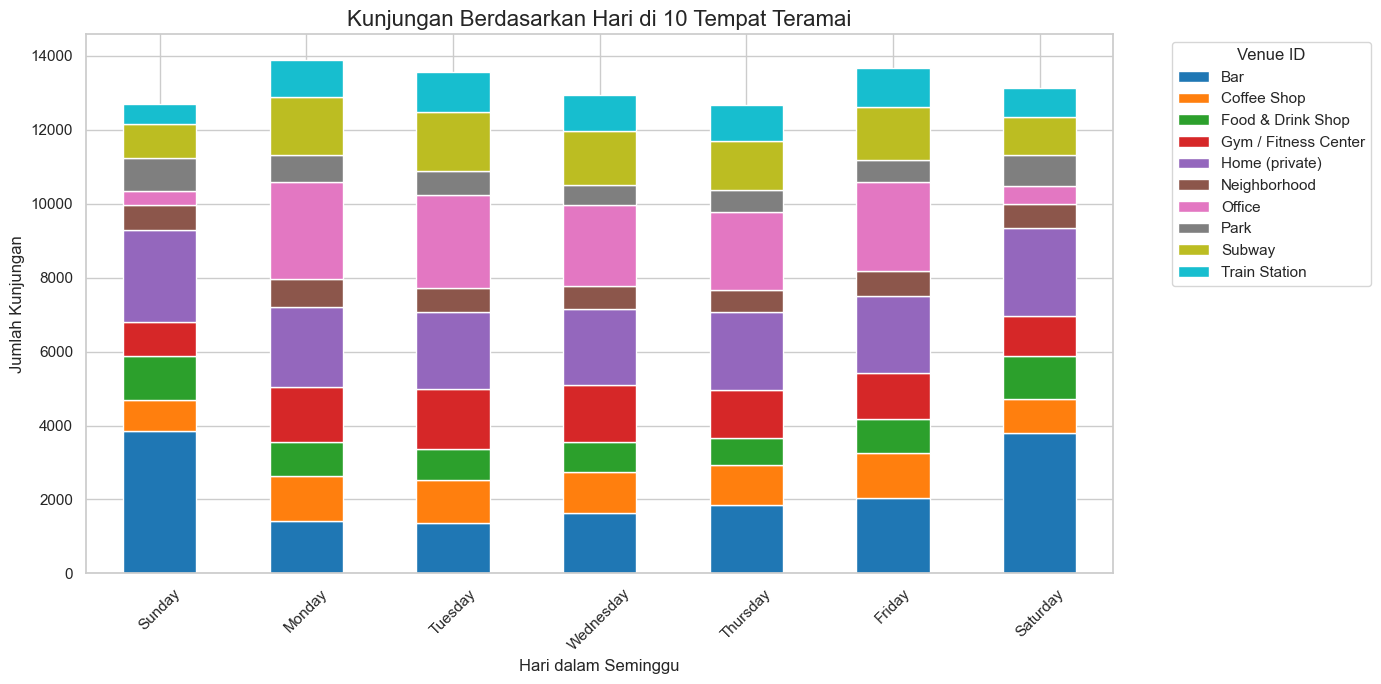

In [98]:
#dataset nyc
sns.set(style="whitegrid")

# Plot visits by day of the week for the top 10 venues
plt.figure(figsize=(12, 6))
visits_by_day.T.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10')
plt.title("Kunjungan Berdasarkan Hari di 10 Tempat Teramai", fontsize=16)
plt.ylabel("Jumlah Kunjungan", fontsize=12)
plt.xlabel("Hari dalam Seminggu", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Venue ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


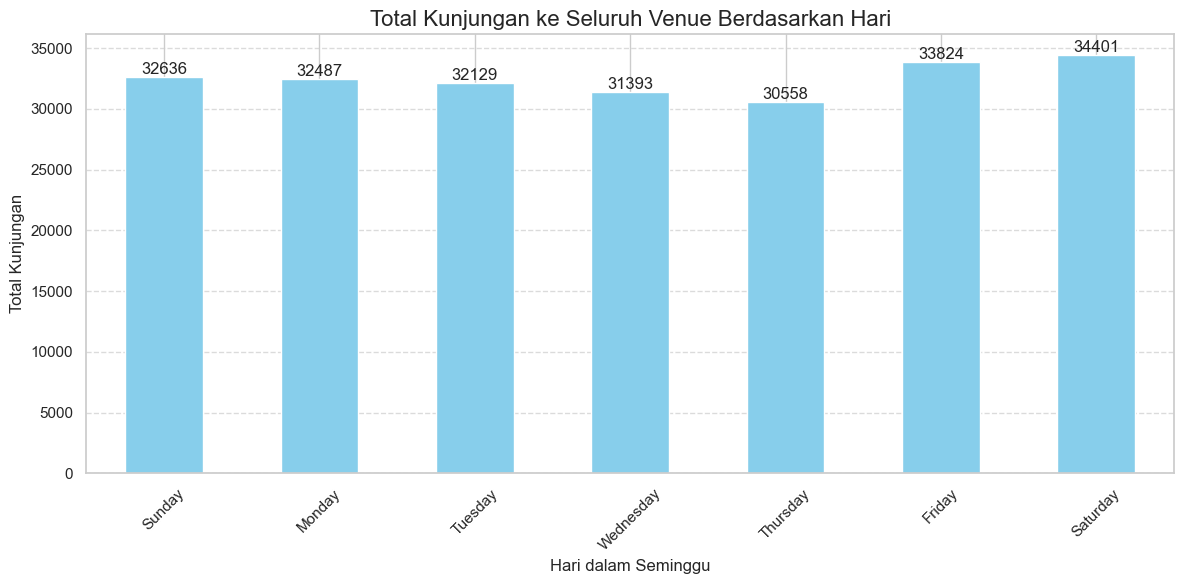

In [99]:
#total kunjungan perh hari ke seluruh venue
total_visits_by_day = data.groupby('day_of_week').size()
total_visits_by_day = total_visits_by_day.reindex(days)
total_visits_by_day

#visualisasi total kunjungan perhari
plt.figure(figsize=(12, 6))
total_visits_by_day.plot(kind='bar', color='skyblue')
plt.title('Total Kunjungan ke Seluruh Venue Berdasarkan Hari', fontsize=16)
plt.xlabel('Hari dalam Seminggu', fontsize=12)
plt.ylabel('Total Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for i, count in enumerate(total_visits_by_day):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.show()


In [100]:
average_visits_per_day = data.groupby('day_of_week')['userId'].value_counts().mean()
print(f'Rata-Rata Kunjungan Perhari Diseluruh Venue di New York City: {average_visits_per_day:.0f} Kunjungan')


Rata-Rata Kunjungan Perhari Diseluruh Venue di New York City: 30 Kunjungan


In [101]:
#dataset tokyo
visits_by_day2


day_of_week,Sunday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
venueCategory,,,,,,,
Bar,2210,1837,1626,1783,1783,2816,2885
Coffee Shop,1407,1356,1258,1240,1321,1044,1333
Convenience Store,2339,2806,2645,2348,2481,2147,2067
Electronics Store,2232,1349,1071,1213,1262,1473,2297
Food & Drink Shop,2852,2175,1755,1679,1689,1587,2286
Japanese Restaurant,2048,2227,2210,2198,2224,2406,2367
Mall,2155,1381,1228,1269,1299,1321,2186
Ramen / Noodle House,2291,2551,2461,2324,2500,2658,2518
Subway,5082,6632,6630,6383,6349,5798,4792


<Figure size 1200x600 with 0 Axes>

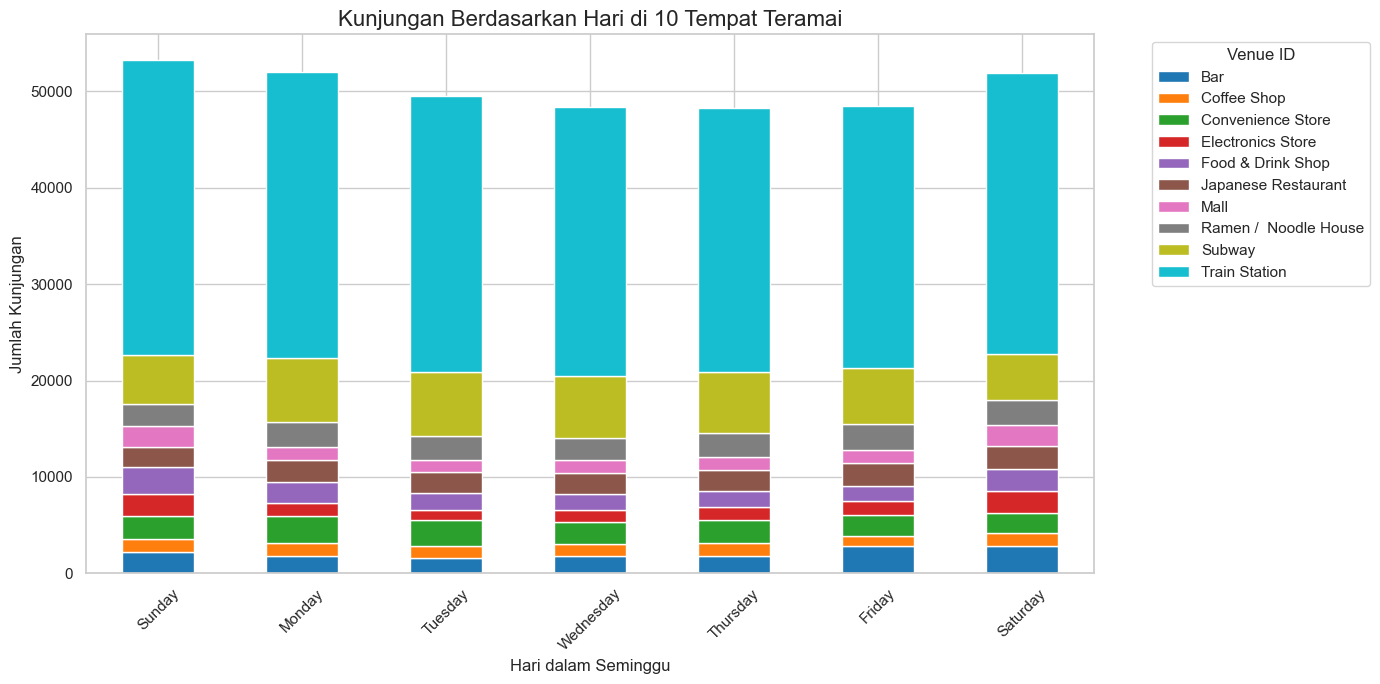

In [102]:
# Set up the visual style
sns.set(style="whitegrid")

# Plot visits by day of the week for the top 10 venues
plt.figure(figsize=(12, 6))
visits_by_day2.T.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10')
plt.title("Kunjungan Berdasarkan Hari di 10 Tempat Teramai", fontsize=16)
plt.ylabel("Jumlah Kunjungan", fontsize=12)
plt.xlabel("Hari dalam Seminggu", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Venue ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


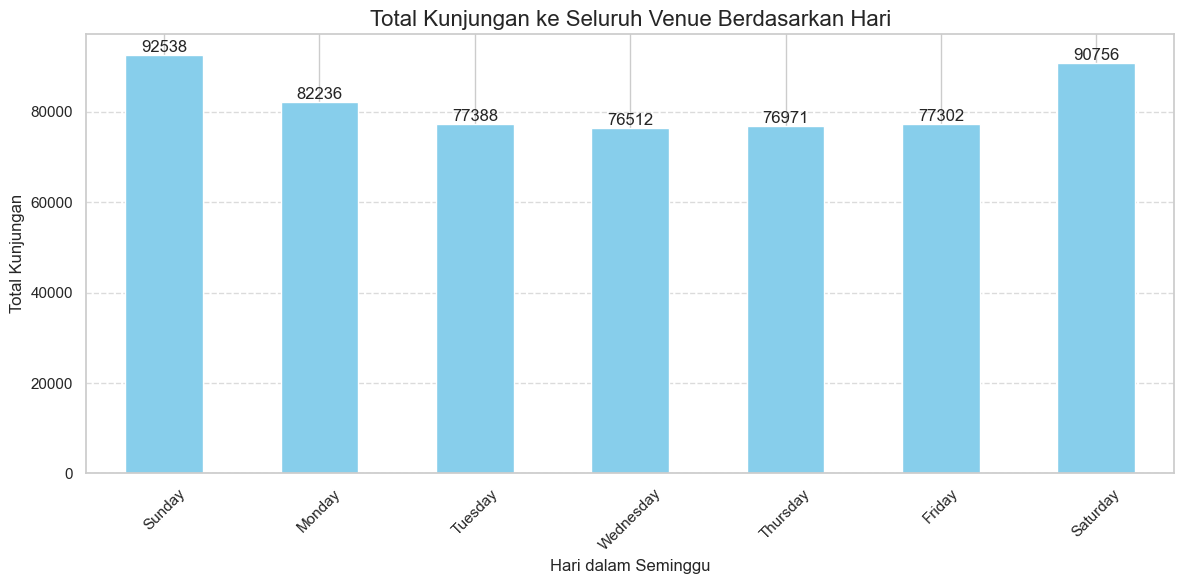

In [103]:
#total kunjungan perh hari ke seluruh venue
total_visits_by_day2 = data2.groupby('day_of_week').size()
total_visits_by_day2 = total_visits_by_day2.reindex(days)
total_visits_by_day2

#visualisasi total kunjungan perhari
#tambahakan nilai total kunjungan perhari

plt.figure(figsize=(12, 6))
total_visits_by_day2.plot(kind='bar', color='skyblue')
plt.title('Total Kunjungan ke Seluruh Venue Berdasarkan Hari', fontsize=16)
plt.xlabel('Hari dalam Seminggu', fontsize=12)
plt.ylabel('Total Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for i, count in enumerate(total_visits_by_day2):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.show()


In [104]:
# tambahkan rata-rata kunjungan perhari
average_visits_per_day2 = data2.groupby('day_of_week')['userId'].value_counts().mean()
print(f'Rata-Rata Kunjungan Perhari Diseluruh Venue di Tokyo: {average_visits_per_day2:.0f} Kunjungan')


Rata-Rata Kunjungan Perhari Diseluruh Venue di Tokyo: 36 Kunjungan


### Jumlah Pengunjung Berdasarkan waktu

In [105]:
visits_by_hour #dataset NYC


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
venueCategory,,,,,,,,,,,,,,,,,,,,,
Bar,1450,1454,1579,1506,1434,1233,808,464,169,108,...,172,158,271,365,445,379,419,618,1042,1393
Coffee Shop,159,128,101,73,41,32,19,18,33,53,...,627,402,407,490,473,476,426,344,327,237
Food & Drink Shop,427,257,161,125,59,39,29,31,22,32,...,313,310,403,508,546,519,509,519,546,501
Gym / Fitness Center,588,277,156,63,28,22,14,22,39,211,...,519,413,515,511,370,315,374,559,817,776
Home (private),961,885,920,981,932,654,505,382,309,290,...,509,471,550,604,516,589,624,710,914,997
Neighborhood,306,217,190,187,123,115,81,65,73,85,...,231,180,208,184,196,223,233,250,284,279
Office,191,143,116,99,58,50,20,23,20,89,...,1718,885,696,736,628,549,369,407,385,310
Park,258,157,117,105,71,34,28,28,49,78,...,187,169,238,329,347,346,354,367,364,304
Subway,449,394,283,251,153,134,58,67,120,173,...,460,358,335,416,401,394,397,540,460,463


In [106]:
#pengelompokkan berdasrkan waktu pagi, malam, siang tempat mana yang ramai dikunjungi di ketiga waktu tersebut
def time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Afternoon'
    elif 15 <= hour < 18:
        return 'Evening'
    else:
        return 'Night'

#aplikasikan fungsi time_of_day ke kolom hour
data['time_of_day'] = data['hour'].apply(time_of_day)

#filter data untuk hanya 10 tempat teratas
top_venues_data = data[data['venueCategory'].isin(top_venues)]

# hitung kunjungan berdasarkan waktu`
visits_by_time = top_venues_data.groupby(['venueCategory', 'time_of_day']).size().unstack(fill_value=0)
time  = ['Morning', 'Afternoon', 'Evening', 'Night']
visits_by_time = visits_by_time.reindex(columns=time)
visits_by_time



time_of_day,Morning,Afternoon,Evening,Night
venueCategory,,,,
Bar,1745,645,636,12952
Coffee Shop,831,2965,897,2817
Food & Drink Shop,314,1163,911,4208
Gym / Fitness Center,1597,2203,1026,4345
Home (private),2478,2067,1154,9683
Neighborhood,670,939,392,2603
Office,964,7039,1432,3305
Park,567,846,567,2824
Subway,1586,2692,751,4319


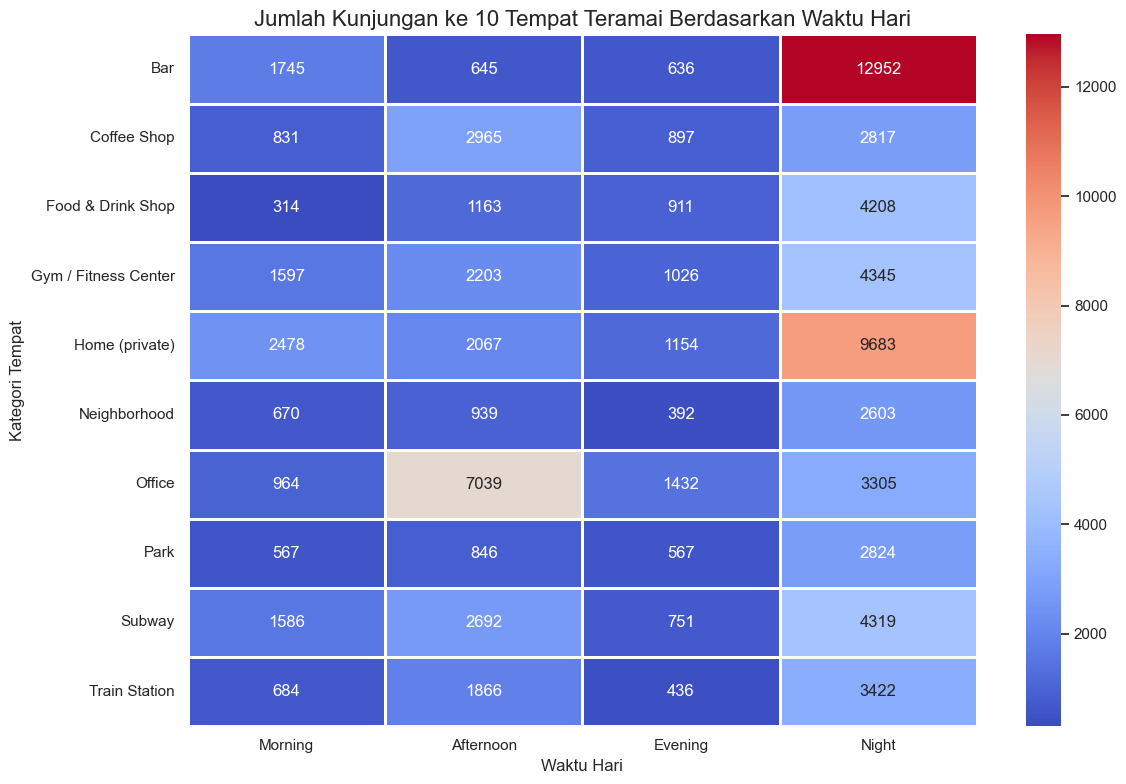

In [107]:
#visualisasi data visit by time
plt.figure(figsize=(12, 8))
sns.heatmap(visits_by_time, cmap='coolwarm', annot=True, fmt='d', linewidths=1)
plt.title('Jumlah Kunjungan ke 10 Tempat Teramai Berdasarkan Waktu Hari', fontsize=16)
plt.xlabel('Waktu Hari', fontsize=12)
plt.ylabel('Kategori Tempat', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


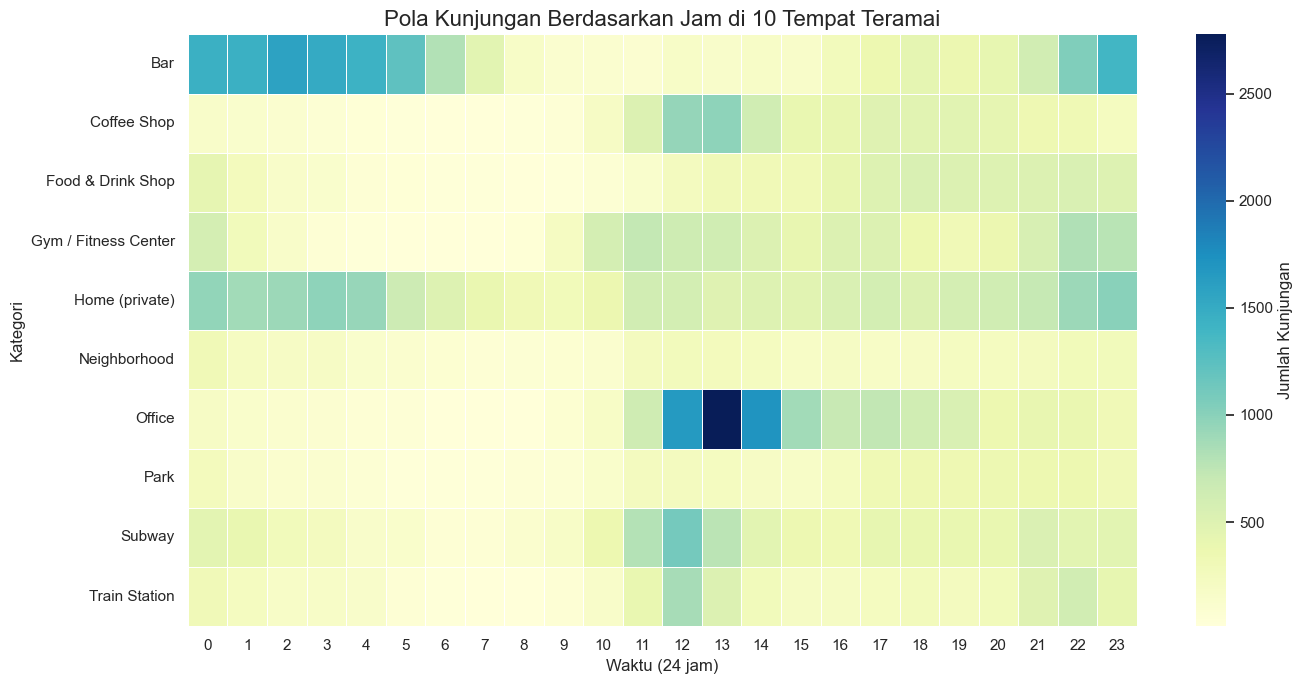

In [108]:
# Heatmap for visits by hour
plt.figure(figsize=(14, 7))
sns.heatmap(visits_by_hour, cmap="YlGnBu", linewidths=.5, annot=False, cbar_kws={'label': 'Jumlah Kunjungan'})
plt.title("Pola Kunjungan Berdasarkan Jam di 10 Tempat Teramai", fontsize=16)
plt.ylabel("Kategori", fontsize=12)
plt.xlabel("Waktu (24 jam)", fontsize=12)
plt.tight_layout()
plt.show()


In [109]:
#kategori waktu yang paling banyak dikunjungi
most_visited_time = data['time_of_day'].value_counts().idxmax()
print(f'Waktu yang Paling Banyak Dikunjungi: {most_visited_time}')


Waktu yang Paling Banyak Dikunjungi: Night


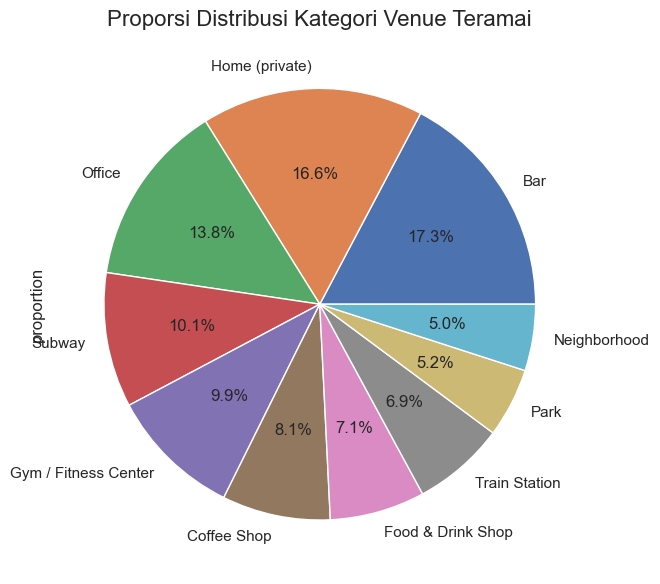

In [110]:
#buat plot proporsi distribusi kategori venue yang teramai
plt.figure(figsize=(10, 6))
data['venueCategory'].value_counts(normalize=True).head(10).plot(kind='pie', color='skyblue', autopct='%1.1f%%')
plt.title('Proporsi Distribusi Kategori Venue Teramai', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [111]:
visits_by_hour2#dataset Tokyo


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
venueCategory,,,,,,,,,,,,,,,,,,,,,
Bar,75,60,180,531,415,300,363,516,954,1630,...,972,509,222,186,100,59,50,27,82,96
Coffee Shop,515,309,345,585,573,642,719,719,713,841,...,39,12,3,1,0,3,24,97,353,799
Convenience Store,953,493,480,989,690,652,676,862,942,1167,...,713,466,197,110,79,77,193,390,976,1371
Electronics Store,115,265,391,543,669,806,972,1151,1231,1596,...,23,8,1,2,0,1,1,4,17,23
Food & Drink Shop,255,337,419,745,614,642,751,1042,1306,1706,...,418,171,71,45,19,27,77,161,217,335
Japanese Restaurant,89,90,521,2022,1296,718,451,400,721,1592,...,467,232,87,46,38,17,54,59,157,184
Mall,480,319,477,592,637,655,824,896,1120,1267,...,95,62,10,9,9,10,30,50,230,353
Ramen / Noodle House,97,138,867,2203,1697,1079,793,599,711,1334,...,541,290,123,72,57,31,45,37,129,171
Subway,2780,1378,1327,1781,1674,1688,1875,2098,2824,4582,...,1529,518,26,32,8,30,219,523,2237,3919


In [132]:
# Apply the function to create a new column
data2['time_of_day'] = data2['hour'].apply(time_of_day)

# Filter the data2 for only the top 10 venues
top_venues_data2 = data2[data2['venueCategory'].isin(top_venues2)]

# Count visits by venueId and time of day
visits_by_time2 = top_venues_data2.groupby(['venueCategory', 'time_of_day']).size().unstack(fill_value=0)

time  = ['Morning', 'Afternoon', 'Evening', 'Night']
visits_by_time2 = visits_by_time2.reindex(columns=time)
visits_by_time2


time_of_day,Morning,Afternoon,Evening,Night
venueCategory,,,,
Bar,7798,4759,408,1975
Coffee Shop,4165,545,4,4245
Convenience Store,6025,3158,307,7343
Electronics Store,7440,619,3,2835
Food & Drink Shop,7796,2263,116,3848
Japanese Restaurant,7376,2926,133,5245
Mall,6165,813,19,3842
Ramen / Noodle House,7210,3347,195,6551
Subway,17973,6071,58,17564


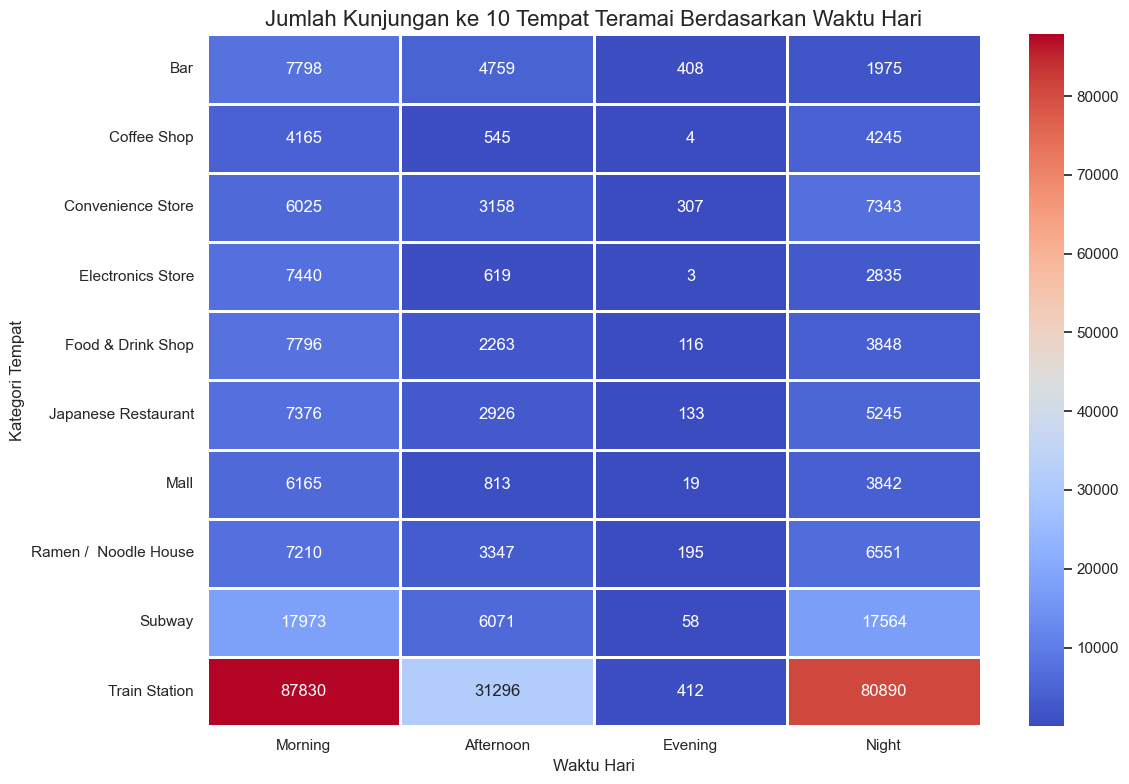

In [134]:
#visualisasi data visit by time
plt.figure(figsize=(12, 8))
sns.heatmap(visits_by_time2, cmap='coolwarm', annot=True, fmt='d', linewidths=1)
plt.title('Jumlah Kunjungan ke 10 Tempat Teramai Berdasarkan Waktu Hari', fontsize=16)
plt.xlabel('Waktu Hari', fontsize=12)
plt.ylabel('Kategori Tempat', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


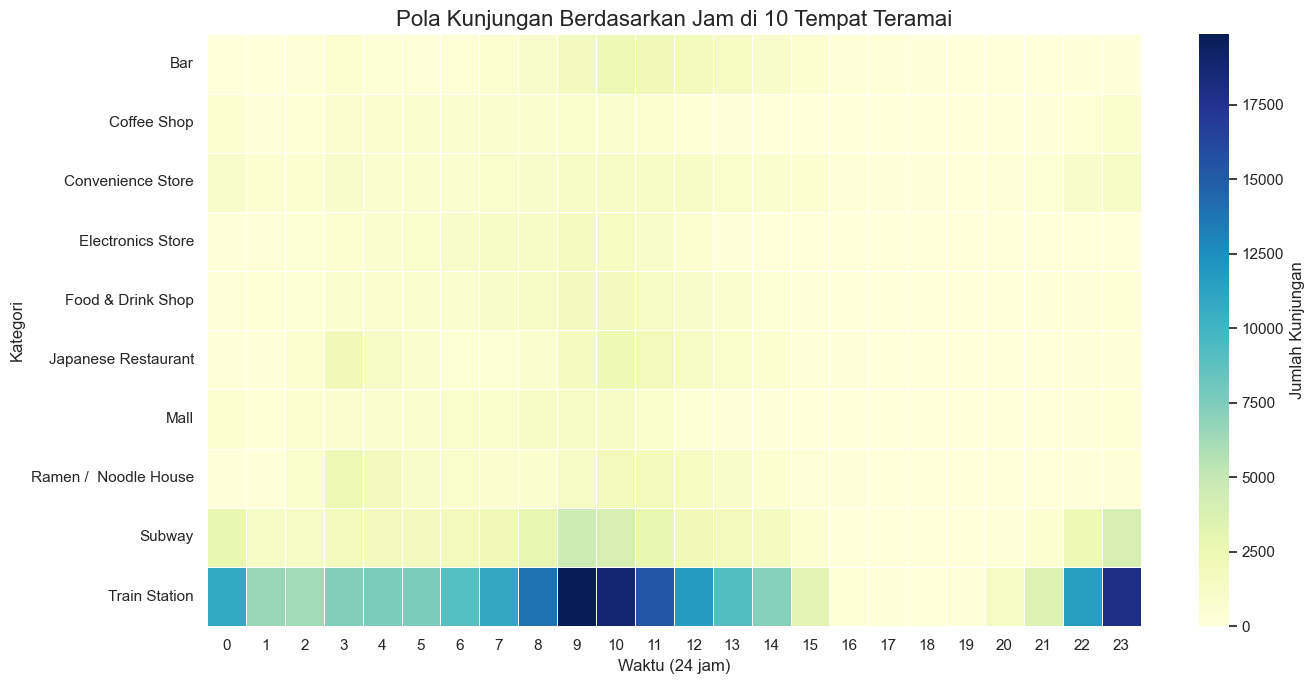

In [135]:
# Heatmap for visits by hour
plt.figure(figsize=(14, 7))
sns.heatmap(visits_by_hour2, cmap="YlGnBu", linewidths=.5, annot=False, cbar_kws={'label': 'Jumlah Kunjungan'})
plt.title("Pola Kunjungan Berdasarkan Jam di 10 Tempat Teramai", fontsize=16)
plt.ylabel("Kategori", fontsize=12)
plt.xlabel("Waktu (24 jam)", fontsize=12)
plt.tight_layout()
plt.show()


In [115]:
most_visited_time2 = data2['time_of_day'].value_counts().idxmax()
print(f'Waktu yang Paling Banyak Dikunjungi: {most_visited_time2}')


Waktu yang Paling Banyak Dikunjungi: Morning


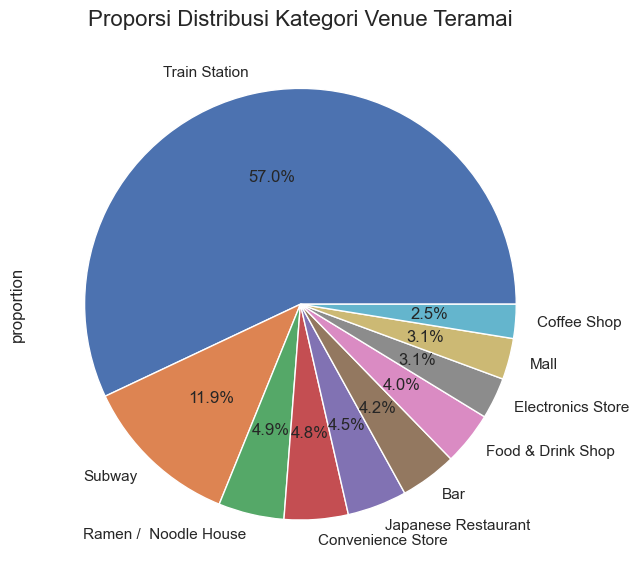

In [116]:
#buat plot proporsi distribusi kategori venue yang teramai
plt.figure(figsize=(10, 6))
data2['venueCategory'].value_counts(normalize=True).head(10).plot(kind='pie', color='skyblue', autopct='%1.1f%%')
plt.title('Proporsi Distribusi Kategori Venue Teramai', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [122]:
#gunakan folium untuk visualisasi data 10 kategori venue teramai di NYC
import folium
from folium.plugins import MarkerCluster

# Create a map centered at the mean latitude and longitude of the data
venue_map1 = folium.Map(location=[data['latitude'].mean(), data['longitude'].mean()], zoom_start=12)

# Create a MarkerCluster object
marker_cluster = MarkerCluster().add_to(venue_map1)

# Add markers to the map
for i, row in top_venues_data.iterrows():
    folium.Marker([row['latitude'], row['longitude']], popup=row['venueCategory']).add_to(marker_cluster)


In [123]:
map_file_path = 'popularity_map_nyc.html'
venue_map1.save(map_file_path)

map_file_path


'popularity_map_nyc.html'

In [124]:
#gunakan folium untuk visualisasi data 10 kategori venue teramai di Tokyo
import folium
from folium.plugins import MarkerCluster

# Create a map centered at the mean latitude and longitude of the data
venue_map2 = folium.Map(location=[data2['latitude'].mean(), data2['longitude'].mean()], zoom_start=12)

# Create a MarkerCluster object
marker_cluster2 = MarkerCluster().add_to(venue_map2)

# Add markers to the map
for i, row in top_venues_data2.iterrows():
    folium.Marker([row['latitude'], row['longitude']], popup=row['venueCategory']).add_to(marker_cluster2)



In [127]:
map_file_path2 = 'popularity_map_tky.html'
venue_map2.save(map_file_path2)

map_file_path2


'popularity_map_tky.html'